<a href="https://colab.research.google.com/github/Ajo-Antony/diffusion-on-Butterfly-dataset-/blob/main/new_Butterfly_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torchvision

from torchvision import transforms
from datasets import load_dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

import torch.nn.functional as F
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
from datasets import load_dataset
from PIL import Image

In [2]:
dataset= load_dataset("huggan/smithsonian_butterflies_subset",split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
image_size=64

preprocess=transforms.Compose([
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ])

In [4]:
dataset.set_transform(preprocess)
batch_size=64
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

device="cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def show_images(image):
    plt.imshow(make_grid(image*0.5+0.5).permute(1,2,0))

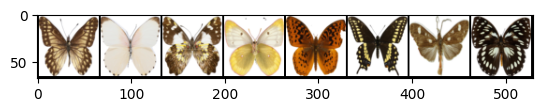

In [6]:
batch=next(iter(train_dataloader))
show_images(batch['images'][:8])

In [7]:
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.02)
model=UNet2DModel(sample_size=64,block_out_channels=(64,128,256,512,512,512,512),
                  down_block_types=('DownBlock2D', 'AttnDownBlock2D', 'AttnDownBlock2D',\
                                    'AttnDownBlock2D','AttnDownBlock2D','AttnDownBlock2D',\
                                    'AttnDownBlock2D'),
                   up_block_types=('AttnUpBlock2D','AttnUpBlock2D','AttnUpBlock2D',\
                                   'AttnUpBlock2D', 'AttnUpBlock2D', 'AttnUpBlock2D',\
                                   'UpBlock2D'))

In [8]:
num_epochs=30
ls=1e-4
model=model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=ls)
losses = []

for epoch in range(num_epochs):
    for step, batch in enumerate(train_dataloader):

        clean_images = batch["images"].to(device)

        noise = torch.randn(clean_images.shape).to(clean_images.device)
        timesteps = torch.randint(
            0,
            scheduler.num_train_timesteps,
            (clean_images.shape[0],),
            device=clean_images.device,
        ).long()

        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        loss = F.mse_loss(noise_pred, noise)

        losses.append(loss.item())
        loss.backward(loss)
        optimizer.step()
        optimizer.zero_grad()
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1} Loss {loss}")

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 10 Loss 0.10868462920188904
Epoch 20 Loss 0.058014847338199615
Epoch 30 Loss 0.04743536561727524


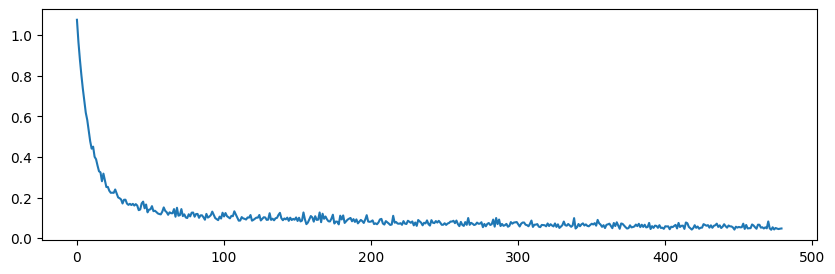

In [9]:
plt.figure(figsize=(10,3))
plt.plot(losses)

In [19]:
from diffusers import DDPMPipeline

pipe= DDPMPipeline(unet=model,scheduler=scheduler)
pipe.to(device)

DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.37.1",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

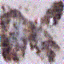

In [17]:
pipe().images[0]


  0%|          | 0/1000 [00:00<?, ?it/s]

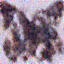

In [18]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

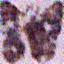

In [21]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

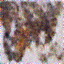

In [22]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

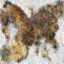

In [23]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

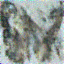

In [24]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

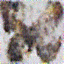

In [25]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

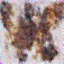

In [26]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

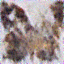

In [27]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

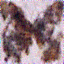

In [28]:
pipe().images[0]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

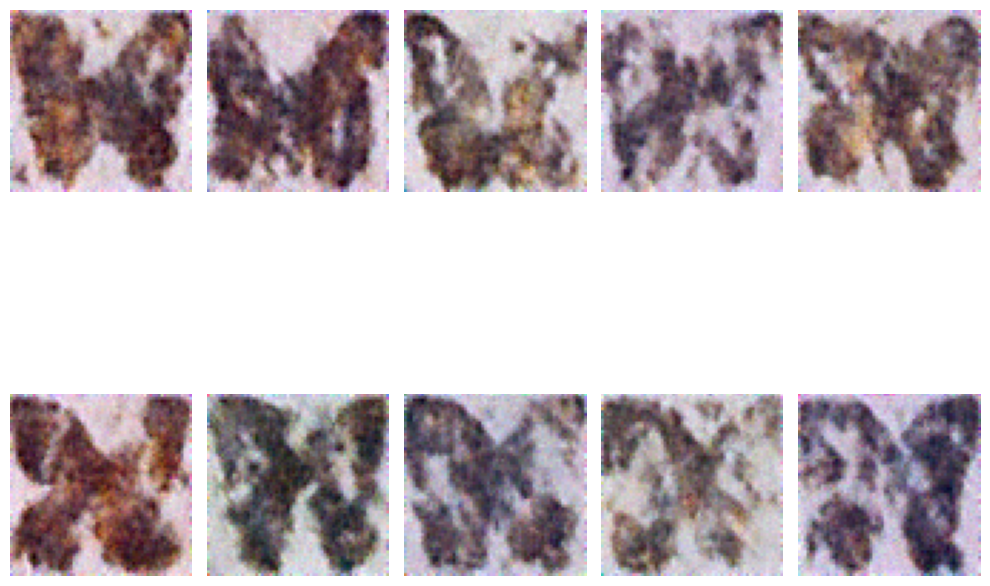

In [30]:
plt.figure(figsize=(10, 10))
for i in range(10):
    image = pipe().images[0]
    plt.subplot(2, 5, i + 1) # Arrange images in a 2x5 grid
    plt.imshow(image)
    plt.axis('off')
plt.tight_layout()
plt.show()